In [1]:
import os
import time
import numpy as np
import polars as pl
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler
import optuna

# Forzamos CPU antes de importar TensorFlow para evitar problemas de cuDNN en este entorno
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# TENSORFLOW / KERAS
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Input

print('TensorFlow configurado en CPU para ejecutar la LSTM de forma estable.')

/mnt/AI-DATA/placivm_tfg/PLACI_TFG/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
I0000 00:00:1774390905.770465   38220 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774390908.181591   38220 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow configurado en CPU para ejecutar la LSTM de forma estable.


In [2]:
# ==========================================
# 0. FUNCIÓN DE VENTANA DESLIZANTE (SLIDING WINDOW)
# ==========================================
def create_sequences(X, y, time_steps):
    """
    Transforma datos tabulares 2D (muestras, características) 
    en tensores 3D (muestras, time_steps, características) para la LSTM.
    """
    Xs, ys = [], []
    for i in range(len(X) - time_steps + 1):
        Xs.append(X[i : (i + time_steps)])
        # La etiqueta será la del ÚLTIMO paquete de la secuencia
        ys.append(y[i + time_steps - 1])
    return np.array(Xs), np.array(ys)

# ==========================================
# 1. CARGA DE DATOS 
# ==========================================
path_train = "../DATASETS/dataSets_Reducidos/nusw-nb15/datos_train_NUSW_redux.csv"
path_test  = "../DATASETS/dataSets_Reducidos/nusw-nb15/datos_test_NUSW_redux.csv"

df_train = pl.read_csv(path_train)
df_test  = pl.read_csv(path_test)
TARGET_COL = "attack_cat"

y_train = (df_train.select(
    pl.when(pl.col(TARGET_COL).str.strip_chars() == "Normal").then(1).otherwise(-1).alias("label")
).to_series().cast(pl.Int8))

y_test = (df_test.select(
    pl.when(pl.col(TARGET_COL).str.strip_chars() == "Normal").then(1).otherwise(-1).alias("label")
).to_series().cast(pl.Int8))

x_train = df_train.drop(TARGET_COL)
x_test  = df_test.drop(TARGET_COL)

X_full_train = x_train.to_numpy()
y_full_train = y_train.to_numpy()
X_test_np = x_test.to_numpy()
y_test_np = y_test.to_numpy()

# Convertimos -1/1 a 0/1 globalmente para la red neuronal
y_full_train_01 = ((y_full_train + 1) // 2).astype(np.int8)

# Nota metodologica: este dataset reducido no incluye un identificador temporal explicito
# (timestamp, flow_id secuencial o sesion) en las variables usadas por la LSTM.
# Por tanto, el orden de las filas no se puede defender como secuencia temporal real
# con la misma solidez que en un problema puramente secuencial. Este modelo debe
# presentarse como experimento exploratorio, no como comparativa principal.
print("Datos cargados. Generando secuencias temporales para LSTM...")



Datos cargados. Generando secuencias temporales para LSTM...


In [3]:
# ==========================================
# 2. FASE OPTUNA 
# ==========================================

def objective(trial):
    # --- HIPERPARÁMETROS ESTRUCTURALES (INFERENCIA) ---
    time_steps = trial.suggest_categorical("time_steps", [3, 5, 10])
    lstm_units = trial.suggest_categorical("lstm_units", [16, 32, 64, 128])
    num_layers = trial.suggest_int("num_layers", 1, 2)
    
    # --- HIPERPARÁMETROS FIJOS (POR DEFECTO) ---
    FIXED_BATCH = 1024
    FIXED_DROPOUT = 0.2

    skf = StratifiedKFold(n_splits=2, shuffle=False) # ¡Sin shuffle!

    f1_scores = []
    latencies = []

    for fold_id, (train_idx, val_idx) in enumerate(skf.split(X_full_train, y_full_train_01), start=1):
        tf.keras.backend.clear_session()

        X_train_cv_raw, X_val_cv_raw = X_full_train[train_idx], X_full_train[val_idx]
        y_train_cv, y_val_cv = y_full_train_01[train_idx], y_full_train_01[val_idx]

        # Escalado ajustado solo con el fold de entrenamiento para evitar data leakage
        scaler = StandardScaler()
        X_train_cv = scaler.fit_transform(X_train_cv_raw)
        X_val_cv = scaler.transform(X_val_cv_raw)

        # Al optimizar 'time_steps', debemos generar las ventanas en cada ciclo
        X_train_seq, y_train_seq = create_sequences(X_train_cv, y_train_cv, time_steps)
        X_val_seq, y_val_seq = create_sequences(X_val_cv, y_val_cv, time_steps)

        # Construcción dinámica de la estructura
        model = Sequential()
        
        # Nueva forma recomendada por Keras para la entrada de datos (quita el Warning)
        model.add(Input(shape=(time_steps, X_train_seq.shape[2])))
        
        if num_layers == 1:
            # Añadimos unroll=True para saltarnos el error de CuDNN del servidor
            model.add(LSTM(lstm_units, unroll=True)) # unroll=True para evitar el error de cuDNN en CPU
        else:
            # Añadimos unroll=True en ambas capas
            model.add(LSTM(lstm_units, return_sequences=True, unroll=True))
            model.add(Dropout(FIXED_DROPOUT))
            model.add(LSTM(lstm_units, unroll=True)) 
            # Aquí hemos añadido 2 capas con el mismo número de unidades para mantener la simplicidad del espacio de búsqueda. Si quisieramos más variedad, podríamos hacer que la segunda capa tenga un número diferente de unidades, pero eso aumentaría el espacio de búsqueda.

        model.add(Dropout(FIXED_DROPOUT)) # Dropout fijo para evitar sobreajuste, especialmente con pocas capas
        model.add(Dense(1, activation='sigmoid'))

        model.compile(optimizer=Adam(), loss='binary_crossentropy')

        early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

        # Entrenamiento silencioso y rápido
        model.fit(
            X_train_seq, y_train_seq,
            validation_data=(X_val_seq, y_val_seq),
            epochs=15, 
            batch_size=FIXED_BATCH,
            callbacks=[early_stop],
            verbose=0
        )

        # Evaluación: Eficacia (F1 macro)
        y_pred_prob = model.predict(X_val_seq, batch_size=FIXED_BATCH, verbose=0)
        y_pred01 = (y_pred_prob > 0.5).astype(np.int8)
        f1_scores.append(f1_score(y_val_seq, y_pred01, average="macro"))

        # Evaluación: Eficiencia (Latencia en Inferencia)
        subset = min(20000, len(X_val_seq))
        X_lat = X_val_seq[:subset]

        rep = 3
        fold_lat = []
        for _ in range(rep):
            t0 = time.perf_counter()
            _ = model.predict(X_lat, batch_size=FIXED_BATCH, verbose=0)
            t1 = time.perf_counter()
            fold_lat.append((t1 - t0) / len(X_lat) * 1000)

        latencies.append(float(np.mean(fold_lat)))

    avg_f1 = float(np.mean(f1_scores))
    avg_lat = float(np.mean(latencies))
    
    # Guardamos los parámetros que interesan como atributos extra si queremos
    trial.set_user_attr("f1_std", float(np.std(f1_scores)))

    return avg_f1, avg_lat

study = optuna.create_study(
    directions=["maximize", "minimize"],
    study_name="tfg_ids_lstm_structural_cv"
)

print("🚀 Iniciando barrido multiobjetivo con LSTM (Solo hiperparámetros estructurales)...")
study.optimize(objective, n_trials=20) # 15 pruebas bastan al reducir el espacio de búsqueda

# ==========================================
# 3. GUARDAR RESULTADOS
# ==========================================
pareto_ids = {t.number for t in study.best_trials}

trials_data = []
for t in study.trials:
    if t.state == optuna.trial.TrialState.COMPLETE:
        trials_data.append({
            "time_steps": t.params["time_steps"],
            "lstm_units": t.params["lstm_units"],
            "num_layers": t.params["num_layers"],
            "f1_macro": t.values[0],
            "latency_ms": t.values[1],
            "is_pareto": t.number in pareto_ids
        })

df_results = pl.DataFrame(trials_data)
df_results.write_csv("lstm_structural_results.csv")
print("\n✅ Resultados guardados en 'lstm_structural_results.csv'")

[I 2026-03-24 23:22:00,423] A new study created in memory with name: tfg_ids_lstm_structural_cv


🚀 Iniciando barrido multiobjetivo con LSTM (Solo hiperparámetros estructurales)...


[I 2026-03-24 23:22:19,693] Trial 0 finished with values: [0.8194173545914687, 0.006531987665221096] and parameters: {'time_steps': 3, 'lstm_units': 16, 'num_layers': 2}.
[I 2026-03-24 23:22:32,919] Trial 1 finished with values: [0.8237763769156039, 0.005415336849788824] and parameters: {'time_steps': 3, 'lstm_units': 16, 'num_layers': 1}.
[I 2026-03-24 23:23:01,352] Trial 2 finished with values: [0.8551866571044814, 0.008414271722237267] and parameters: {'time_steps': 3, 'lstm_units': 64, 'num_layers': 1}.
[I 2026-03-24 23:23:26,132] Trial 3 finished with values: [0.8539241555680745, 0.008007354630778233] and parameters: {'time_steps': 3, 'lstm_units': 128, 'num_layers': 1}.
[I 2026-03-24 23:24:00,910] Trial 4 finished with values: [0.8660615259396282, 0.010173085223262511] and parameters: {'time_steps': 5, 'lstm_units': 128, 'num_layers': 1}.
[I 2026-03-24 23:25:50,210] Trial 5 finished with values: [0.8551382427945922, 0.031343497413521014] and parameters: {'time_steps': 10, 'lstm_u


✅ Resultados guardados en 'lstm_structural_results.csv'


In [3]:
# ==========================================
# 3. NOTA
# ==========================================
# El notebook conserva un unico bloque `objective` para la optimizacion con Optuna.
# Este bloque duplicado antiguo se elimina para mejorar la trazabilidad experimental.


[I 2026-03-16 20:28:35,351] A new study created in memory with name: tfg_ids_lstm_structural_cv


🚀 Iniciando optimización... (Tomará algo de tiempo, deja a la CPU trabajar)


I0000 00:00:1773689316.059830    5976 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 42480 MB memory:  -> device: 0, name: NVIDIA L40S, pci bus id: 0000:4a:00.0, compute capability: 8.9
I0000 00:00:1773689316.060984    5976 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 43054 MB memory:  -> device: 1, name: NVIDIA L40S, pci bus id: 0000:61:00.0, compute capability: 8.9
I0000 00:00:1773689316.062009    5976 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 43054 MB memory:  -> device: 2, name: NVIDIA L40S, pci bus id: 0000:ca:00.0, compute capability: 8.9
I0000 00:00:1773689316.063034    5976 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 43054 MB memory:  -> device: 3, name: NVIDIA L40S, pci bus id: 0000:e1:00.0, compute capability: 8.9
I0000 00:00:1773689317.984127    6620 service.cc:153] XLA service 0x7fe83c02ffe0 initialized for platfor


✅ Resultados guardados en 'lstm_structural_results.csv'


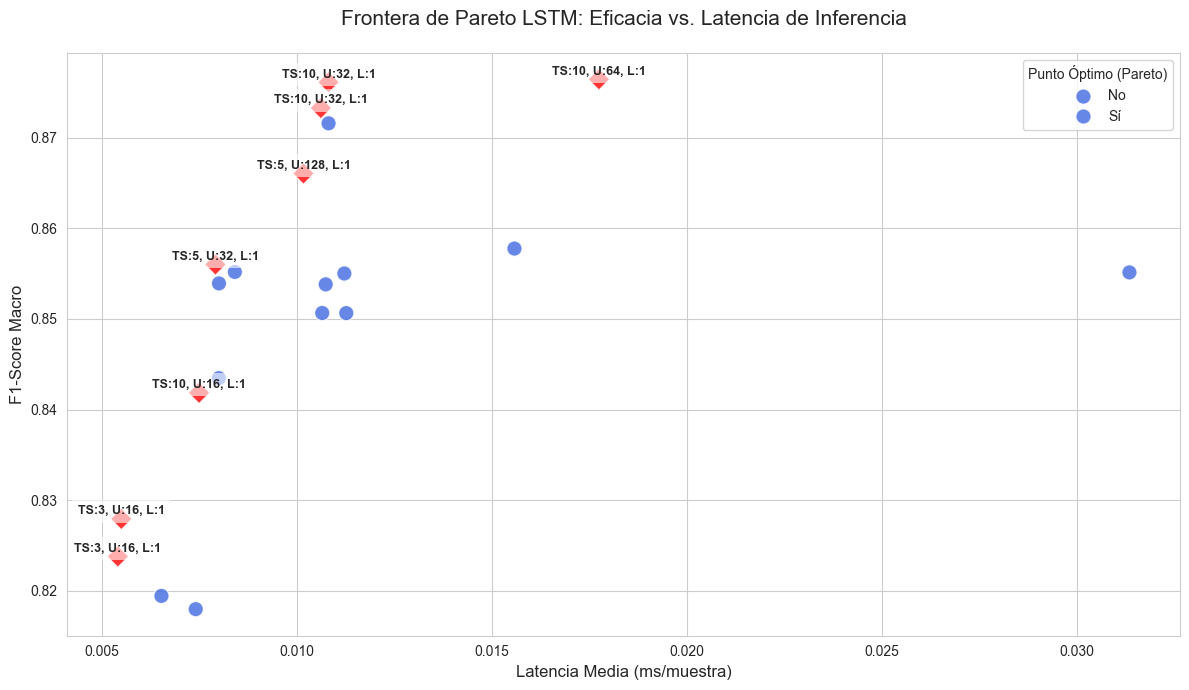

In [4]:
# REPRESENTAMOS LA FRONTERA DE PARETO (ADAPTADO PARA LSTM)
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl

# 1. Cargar resultados
df = pl.read_csv("lstm_structural_results.csv")

plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# 2. Dibujar todos los puntos
sns.scatterplot(
    x=df["latency_ms"].to_numpy(),
    y=df["f1_macro"].to_numpy(),
    hue=df["is_pareto"].to_numpy(),
    palette={True: "red", False: "royalblue"},
    style=df["is_pareto"].to_numpy(),
    markers={True: "D", False: "o"},
    s=120, # Un poco más grandes para que se vean bien
    alpha=0.8
)

# 3. Etiquetar SOLO los puntos de la Frontera de Pareto
pareto_points = df.filter(pl.col("is_pareto") == True)

for row in pareto_points.iter_rows(named=True):
    # Creamos una etiqueta que describa la arquitectura de la red
    label = f"TS:{int(row['time_steps'])}, U:{int(row['lstm_units'])}, L:{int(row['num_layers'])}"
    
    plt.text(
        row["latency_ms"], 
        row["f1_macro"] + 0.0002, # Un pequeño ajuste hacia arriba para que no pise el punto
        label,
        fontsize=9, 
        fontweight='bold', 
        ha='center',
        va='bottom',
        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none') # Fondo sutil para legibilidad
    )

# 4. Estética de la gráfica
plt.title("Frontera de Pareto LSTM: Eficacia vs. Latencia de Inferencia", fontsize=15, pad=20)
plt.xlabel("Latencia Media (ms/muestra)", fontsize=12)
plt.ylabel("F1-Score Macro", fontsize=12)
plt.legend(title="Punto Óptimo (Pareto)", labels=["No", "Sí"])

# Opcional: Ajustar límites para que las etiquetas no se corten
plt.tight_layout()

plt.show()


/mnt/AI-DATA/placivm_tfg/PLACI_TFG/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


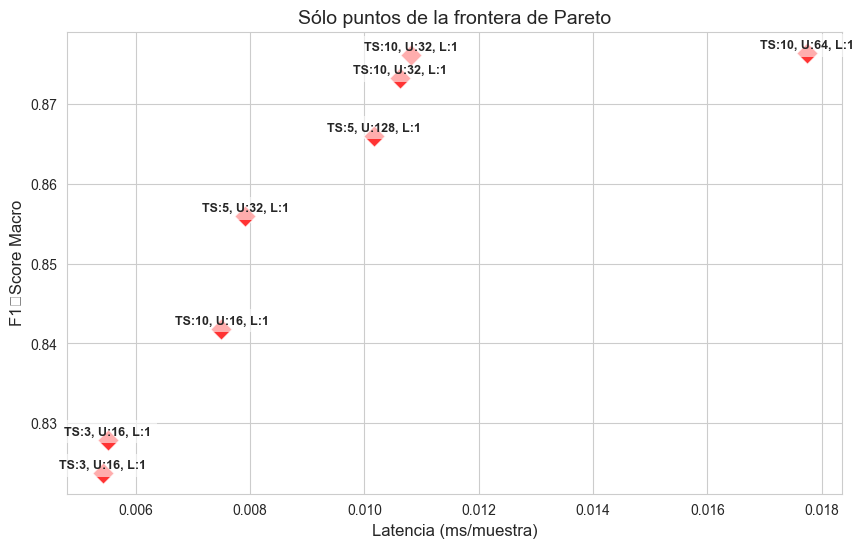

Modelos en la frontera de Pareto:


time_steps,lstm_units,num_layers,f1_macro,latency_ms
i64,i64,i64,f64,f64
3,16,1,0.823776,0.005415
5,128,1,0.866062,0.010173
3,16,1,0.827924,0.005504
5,32,1,0.856016,0.007916
10,16,1,0.841846,0.007497
10,32,1,0.873285,0.010619
10,32,1,0.876134,0.010816
10,64,1,0.876462,0.017746


In [5]:
# AHORA SOLO REPRESENTAMOS LOS MODELOS DE LA FRONTERA DE PARETO

df = pl.read_csv("lstm_structural_results.csv")
pareto_df = df.filter(pl.col("is_pareto") == True)

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

sns.scatterplot(
    x=pareto_df["latency_ms"].to_numpy(),
    y=pareto_df["f1_macro"].to_numpy(),
    color="red",
    marker="D",
    s=120,
    alpha=0.8
)


for row in pareto_points.iter_rows(named=True):
    # Creamos una etiqueta que describa la arquitectura de la red
    label = f"TS:{int(row['time_steps'])}, U:{int(row['lstm_units'])}, L:{int(row['num_layers'])}"
    
    plt.text(
        row["latency_ms"], 
        row["f1_macro"] + 0.0002, # Un pequeño ajuste hacia arriba para que no pise el punto
        label,
        fontsize=9, 
        fontweight='bold', 
        ha='center',
        va='bottom',
        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none') # Fondo sutil para legibilidad
    )

plt.title("Sólo puntos de la frontera de Pareto", fontsize=14)
plt.xlabel("Latencia (ms/muestra)", fontsize=12)
plt.ylabel("F1‑Score Macro", fontsize=12)
plt.show()

# Lista de los modelos en la frontera de Pareto
print("Modelos en la frontera de Pareto:")
display(pareto_df.select(["time_steps", "lstm_units", "num_layers", "f1_macro", "latency_ms"]))

In [6]:
from sklearn.metrics import accuracy_score

# ==========================================
# EVALUACIÓN FINAL EN TEST (3 CANDIDATOS LSTM)
# ==========================================

# Definimos los 3 mejores según tu frontera de Pareto
candidatos = [
    {"ts": 10, "u": 32, "l": 1, "nombre": "Candidato 1"},
    {"ts": 5, "u": 128,  "l": 1, "nombre": "Candidato 2"},
    {"ts": 5,  "u": 32,  "l": 1, "nombre": "Candidato 3"},
    {"ts": 10,  "u": 64,  "l": 1, "nombre": "Candidato 4"},
]

resultados_finales = []

print("--- EVALUACIÓN FINAL SOBRE EL SET DE TEST (LSTM) ---\n")

# Aseguramos etiquetas 0/1
y_full_train01 = ((y_full_train + 1) // 2).astype(np.int8)
y_test_np01    = ((y_test_np + 1) // 2).astype(np.int8)

# Escalado global solo para la fase final train/test
scaler_final = StandardScaler()
X_full_train_scaled = scaler_final.fit_transform(X_full_train)
X_test_scaled = scaler_final.transform(X_test_np)

for c in candidatos:
    print(f"🚀 Entrenando Perfil: {c['nombre']} (TS={c['ts']}, Units={c['u']}, Layers={c['l']})...")

    # 1. Crear secuencias específicas para este candidato con datos escalados
    X_train_seq, y_train_seq = create_sequences(X_full_train_scaled, y_full_train_01, c["ts"])
    X_test_seq, y_test_seq   = create_sequences(X_test_scaled, y_test_np01, c["ts"])

    # 2. Construir arquitectura
    model = Sequential()
    model.add(Input(shape=(c["ts"], X_train_seq.shape[2])))
    
    if c["l"] == 1:
        model.add(LSTM(c["u"], unroll=True))
    else:
        model.add(LSTM(c["u"], return_sequences=True, unroll=True))
        model.add(Dropout(0.2))
        model.add(LSTM(c["u"], unroll=True))
    
    model.add(Dropout(0.2))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(optimizer='adam', loss='binary_crossentropy')

    # 3. Entrenamiento final
    early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    model.fit(
        X_train_seq, y_train_seq,
        validation_split=0.1,
        epochs=20, 
        batch_size=1024,
        callbacks=[early_stop],
        verbose=0
    )

    # 4. Medir Latencia e Inferencia
    # Warm-up (necesario en GPU para estabilizar relojes)
    _ = model.predict(X_test_seq[:min(1000, len(X_test_seq))], verbose=0)

    t0 = time.perf_counter()
    y_pred_prob = model.predict(X_test_seq, batch_size=1024, verbose=0)
    t1 = time.perf_counter()
    
    y_pred01 = (y_pred_prob > 0.5).astype(np.int8).flatten()

    # 5. Cálculo de métricas
    tiempo_total = t1 - t0
    latencia = (tiempo_total / len(y_test_seq)) * 1000
    f1_test = f1_score(y_test_seq, y_pred01, average="macro")
    acc_test = accuracy_score(y_test_seq, y_pred01)

    resultados_finales.append({
        "Perfil": c["nombre"],
        "TS": c["ts"],
        "Units": c["u"],
        "Layers": c["l"],
        "F1_Test": float(f1_test),
        "Accuracy_Test": float(acc_test),
        "Latencia_ms": float(latencia)
    })
    print(f"✅ Finalizado: F1={f1_test:.4f} | Latencia={latencia:.6f} ms\n")

# 6. Mostrar tabla comparativa
df_final_lstm = pl.DataFrame(resultados_finales)
print("\n" + "="*70)
print("              TABLA COMPARATIVA FINAL (LSTM - TEST SET)")
print("="*70)
print(df_final_lstm)

--- EVALUACIÓN FINAL SOBRE EL SET DE TEST (LSTM) ---

🚀 Entrenando Perfil: Candidato 1 (TS=10, Units=32, Layers=1)...
✅ Finalizado: F1=0.9182 | Latencia=0.008000 ms

🚀 Entrenando Perfil: Candidato 2 (TS=5, Units=128, Layers=1)...
✅ Finalizado: F1=0.8932 | Latencia=0.007129 ms

🚀 Entrenando Perfil: Candidato 3 (TS=5, Units=32, Layers=1)...
✅ Finalizado: F1=0.8864 | Latencia=0.004702 ms

🚀 Entrenando Perfil: Candidato 4 (TS=10, Units=64, Layers=1)...
✅ Finalizado: F1=0.9140 | Latencia=0.014846 ms


              TABLA COMPARATIVA FINAL (LSTM - TEST SET)
shape: (4, 7)
┌─────────────┬─────┬───────┬────────┬──────────┬───────────────┬─────────────┐
│ Perfil      ┆ TS  ┆ Units ┆ Layers ┆ F1_Test  ┆ Accuracy_Test ┆ Latencia_ms │
│ ---         ┆ --- ┆ ---   ┆ ---    ┆ ---      ┆ ---           ┆ ---         │
│ str         ┆ i64 ┆ i64   ┆ i64    ┆ f64      ┆ f64           ┆ f64         │
╞═════════════╪═════╪═══════╪════════╪══════════╪═══════════════╪═════════════╡
│ Candidato 1 ┆ 10  ┆ 32    

Generando métricas finales para el modelo: TS=10, Units=128, Layers=2


I0000 00:00:1773690829.106268    6619 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_362970__.27
I0000 00:00:1773690834.690127    6619 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_362970__.27
I0000 00:00:1773690847.034572    6622 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_374033__.1
I0000 00:00:1773690848.764202    6622 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_374715__.1


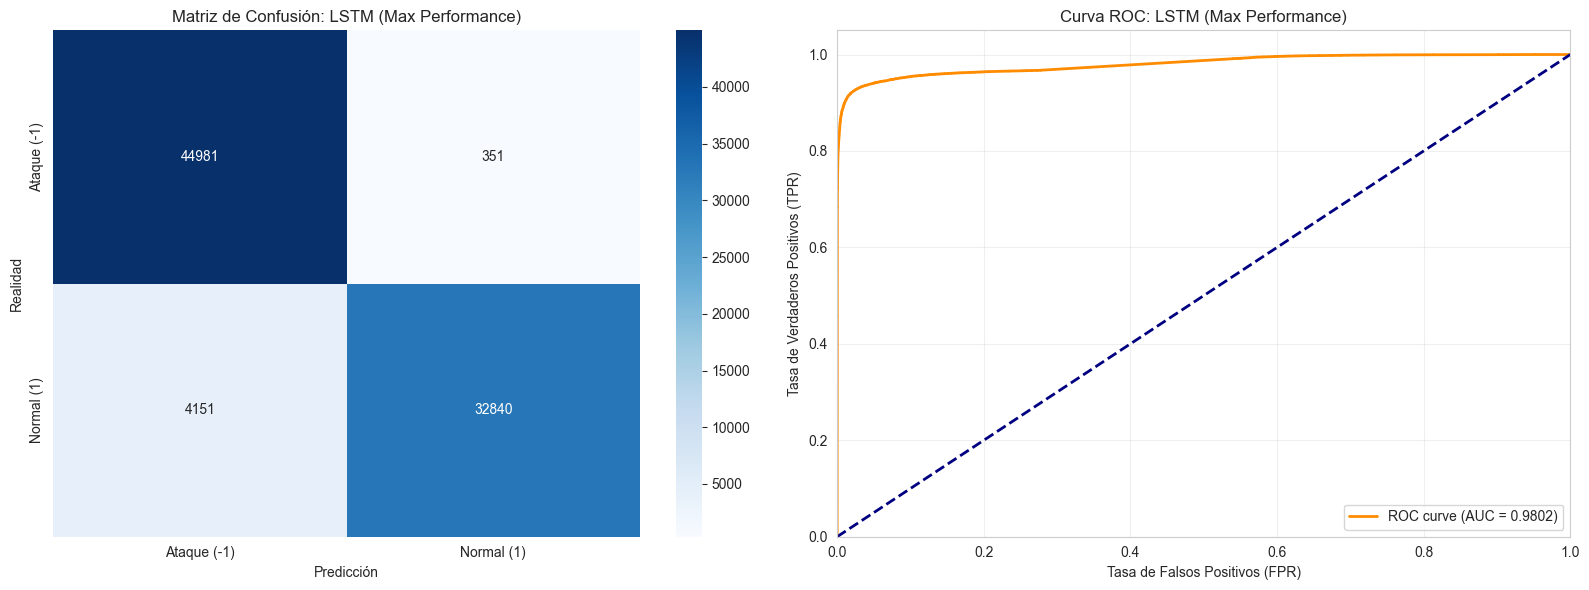


✅ Análisis completado. El AUC final es de: 0.9802


In [11]:
# CURVA ROC Y MATRIZ DE CONFUSIÓN PARA EL MEJOR MODELO

import os
import psutil
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay

# ==========================================
# 1. ENTRENAMIENTO DEL MODELO GANADOR
# ==========================================
best_c = {"ts": 10, "u": 128, "l": 2}

print(f"Generando métricas finales para el modelo: TS={best_c['ts']}, Units={best_c['u']}, Layers={best_c['l']}")

# Re-generamos las secuencias para el mejor modelo con datos escalados
scaler_best = StandardScaler()
X_full_train_scaled = scaler_best.fit_transform(X_full_train)
X_test_scaled = scaler_best.transform(X_test_np)
X_train_seq, y_train_seq = create_sequences(X_full_train_scaled, y_full_train_01, best_c["ts"])
X_test_seq, y_test_seq   = create_sequences(X_test_scaled, y_test_np01, best_c["ts"])

# Definimos la arquitectura ganadora
model_final = Sequential([
    Input(shape=(best_c["ts"], X_train_seq.shape[2])),
    LSTM(best_c["u"], return_sequences=True, unroll=True),
    Dropout(0.2),
    LSTM(best_c["u"], unroll=True),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model_final.compile(optimizer='adam', loss='binary_crossentropy')
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
model_final.fit(X_train_seq, y_train_seq, validation_split=0.1, epochs=20, batch_size=1024, callbacks=[early_stop], verbose=0)

# ==========================================
# 2. BENCHMARK DE RECURSOS COMPUTACIONALES
# ==========================================
print("Midiendo recursos computacionales del modelo ganador (LSTM)...")
proceso = psutil.Process(os.getpid())
block_size = 2048
repetitions = 3

# Warm-up fuera de la medicion
_ = model_final.predict(X_test_seq[:min(512, len(X_test_seq))], batch_size=512, verbose=0)

tiempos_muro = []
tiempos_cpu = []
picos_ram = []

for _ in range(repetitions):
    cpu_ini = proceso.cpu_times()
    ram_base = proceso.memory_info().rss / (1024 * 1024)
    pico_ram_rep = ram_base

    t0 = time.perf_counter()
    for inicio in range(0, len(X_test_seq), block_size):
        fin = inicio + block_size
        bloque = X_test_seq[inicio:fin]
        _ = model_final.predict(bloque, batch_size=512, verbose=0)

        ram_actual = proceso.memory_info().rss / (1024 * 1024)
        if ram_actual > pico_ram_rep:
            pico_ram_rep = ram_actual

    t1 = time.perf_counter()
    cpu_fin = proceso.cpu_times()

    tiempos_muro.append(t1 - t0)
    tiempos_cpu.append((cpu_fin.user - cpu_ini.user) + (cpu_fin.system - cpu_ini.system))
    picos_ram.append(pico_ram_rep - ram_base)

media_muro = float(np.mean(tiempos_muro))
media_cpu = float(np.mean(tiempos_cpu))
pico_max_ram = float(np.max(picos_ram))
total_nucleos = psutil.cpu_count(logical=True)

df_benchmark_lstm = pl.DataFrame([{
    "Modelo": "LSTM",
    "Latencia_ms": round((media_muro / len(X_test_seq)) * 1000, 5),
    "Thruput (paq/s)": round(len(X_test_seq) / media_muro, 0),
    "Núcleos CPU": round(media_cpu / media_muro if media_muro > 0 else 1, 1),
    "Pico RAM (MB)": round(pico_max_ram, 2),
    "Porcentaje CPU": round(((media_cpu / media_muro) / total_nucleos) * 100 if media_muro > 0 else 0, 1)
}])

print(df_benchmark_lstm)

# ==========================================
# 3. OBTENCIÓN DE PREDICCIONES
# ==========================================
y_pred_probs = model_final.predict(X_test_seq, batch_size=1024, verbose=0).ravel()
y_pred_classes = (y_pred_probs > 0.5).astype(np.int8)

# ==========================================
# 4. REPRESENTACIÓN GRÁFICA
# ==========================================
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# --- GRÁFICA 1: MATRIZ DE CONFUSIÓN ---
cm = confusion_matrix(y_test_seq, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0], 
            xticklabels=['Ataque (0)', 'Normal (1)'], 
            yticklabels=['Ataque (0)', 'Normal (1)'])
ax[0].set_title('Matriz de Confusión: LSTM (Max Performance)')
ax[0].set_xlabel('Predicción')
ax[0].set_ylabel('Realidad')

# --- GRÁFICA 2: CURVA ROC ---
fpr, tpr, _ = roc_curve(y_test_seq, y_pred_probs)
roc_auc = auc(fpr, tpr)

ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[1].set_xlim([0.0, 1.0])
ax[1].set_ylim([0.0, 1.05])
ax[1].set_xlabel('Tasa de Falsos Positivos (FPR)')
ax[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax[1].set_title('Curva ROC: LSTM (Max Performance)')
ax[1].legend(loc="lower right")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ Análisis completado. El AUC final es de: {roc_auc:.4f}")